# Section 5.3

## Example 5.3.1

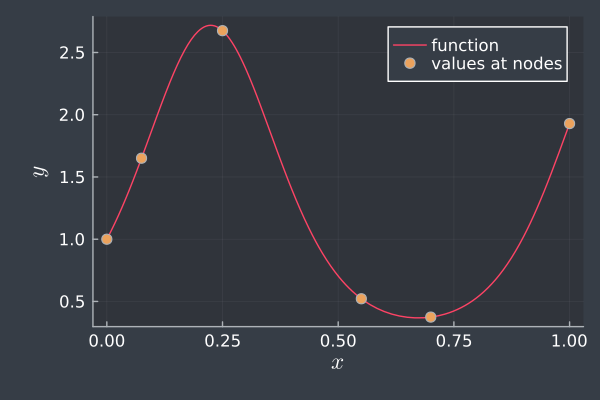

In [1]:
using Plots, LaTeXStrings
theme(:dark); default(thickness_scaling=1.4)

f(x) = exp(sin(7x))
plot(f, 0, 1, label="function", xlabel=L"x", ylabel=L"y")

t = [0, 0.075, 0.25, 0.55, 0.7, 1]  # nodes
y = f.(t)                           # values at nodes
scatter!(t, y, label="values at nodes")

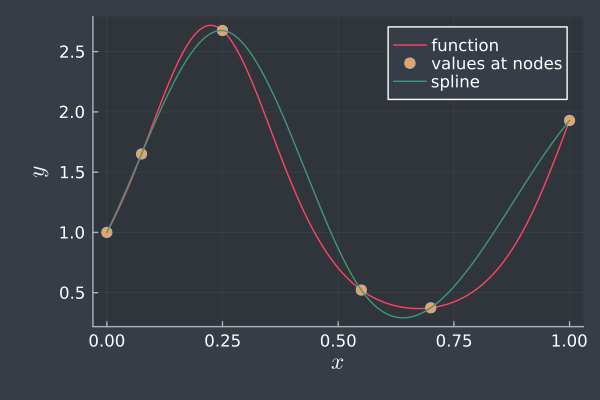

In [2]:
using FNCFunctions

S = FNC.spinterp(t, y)
plot!(S, 0, 1, label="spline")

In [3]:
using LinearAlgebra, PrettyTables

x = (0:10000) / 1e4              # sample the difference at many points
n = @. round(Int, 2^(3:0.5:7))  # numbers of nodes
err = zeros(length(n))
for (k, n) in enumerate(n)
    t = (0:n) / n
    S = FNC.spinterp(t, f.(t))
    dif = @. f(x) - S(x)
    err[k] = norm(dif, Inf)
end
pretty_table((n=n[1:2:end], err=err[1:2:end]); column_labels=["n", "max-norm error"], backend=:html)

n,max-norm error
8,0.0305634
16,0.00590761
32,0.000367049
64,2.15306e-5
128,1.24012e-6


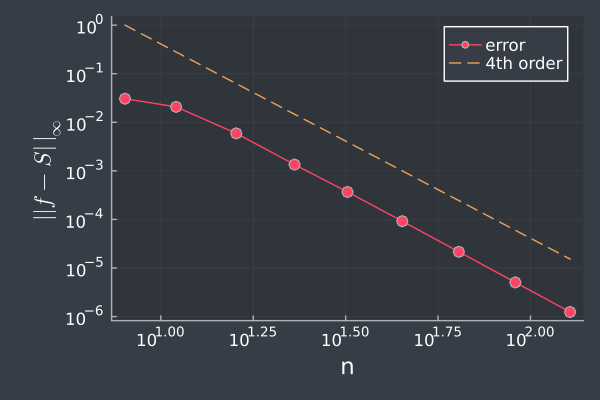

In [4]:
order4 = @. (n / n[1])^(-4)

plot(n, [err order4]; m=[:o :none], l=[:solid :dash], label=["error" "4th order"], 
    xaxis=(:log10, "n"),  yaxis=(:log10, L"|| f-S\,||_\infty"))